# ch306 — Backpropagation from Scratch

## 1. The problem backprop solves

After the forward pass *(ch304)* we have a scalar loss $\mathcal{L}$.
We need $\frac{\partial \mathcal{L}}{\partial W^{[l]}}$ and
$\frac{\partial \mathcal{L}}{\partial b^{[l]}}$ for every layer $l$,
so that gradient descent *(ch307)* can update the parameters.

Naively differentiating through a 50-layer network by hand is infeasible.
Backpropagation (Rumelhart, Hinton, Williams, 1986) is the **efficient algorithm for this**:
it applies the chain rule *(ch215)* in reverse topological order through the computation graph,
reusing intermediate results so each gradient is computed exactly once.

**Cost:** one backward pass ≈ 2–3× the cost of one forward pass. Compare to finite differences:
$O(p)$ forward passes for $p$ parameters — completely infeasible for millions of parameters.

---

## 2. Deriving the equations

Define the upstream gradient at layer $l$ as:
$$
dA^{[l]} = \frac{\partial \mathcal{L}}{\partial A^{[l]}}
$$

Working backwards from the loss:

**Step 1 — Activation backward:**
$$
dZ^{[l]} = dA^{[l]} \odot \sigma'^{[l]}(Z^{[l]})
$$
where $\odot$ is elementwise multiplication and $\sigma'$ is the derivative of the activation.

**Step 2 — Linear backward:**
$$
dW^{[l]} = \frac{1}{B} \, dZ^{[l]} (A^{[l-1]})^\top
$$
$$
db^{[l]} = \frac{1}{B} \sum_{\text{batch}} dZ^{[l]}
$$
$$
dA^{[l-1]} = (W^{[l]})^\top dZ^{[l]}
$$

The last equation propagates the gradient to the previous layer.
Repeat for $l = L, L-1, \ldots, 1$.

*(Chain rule: ch215. Matrix transpose: ch154. Partial derivatives: ch210.)*

In [1]:
import numpy as np


# ─────────────────────────────────────────────────────────────
# Activation functions and their exact derivatives
# ─────────────────────────────────────────────────────────────

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
    z_s = z - z.max(axis=0, keepdims=True)
    e = np.exp(z_s)
    return e / e.sum(axis=0, keepdims=True)


# ─────────────────────────────────────────────────────────────
# Full MLP with forward + backward
# ─────────────────────────────────────────────────────────────

class MLPNumPy:
    """
    Feedforward network implemented entirely in NumPy.
    Supports arbitrary depth; last layer uses sigmoid for binary classification.
    Hidden layers use ReLU.
    """

    def __init__(self, layer_sizes: list, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.params = {}
        self.n_layers = len(layer_sizes) - 1
        for l in range(1, len(layer_sizes)):
            fan_in = layer_sizes[l - 1]
            fan_out = layer_sizes[l]
            self.params[f'W{l}'] = rng.normal(0, np.sqrt(2.0 / fan_in), (fan_out, fan_in))
            self.params[f'b{l}'] = np.zeros(fan_out)

    def forward(self, X: np.ndarray) -> tuple:
        """
        X: shape (n_features, batch_size)
        Returns (output, cache)
        """
        cache = {'A0': X}
        A = X
        for l in range(1, self.n_layers + 1):
            W = self.params[f'W{l}']
            b = self.params[f'b{l}'][:, None]
            Z = W @ A + b
            cache[f'Z{l}'] = Z
            # Last layer: sigmoid; hidden layers: relu
            A = sigmoid(Z) if l == self.n_layers else relu(Z)
            cache[f'A{l}'] = A
        return A, cache

    def bce_loss(self, output: np.ndarray, y: np.ndarray) -> float:
        eps = 1e-12
        p = np.clip(output, eps, 1 - eps)
        return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

    def backward(self, y: np.ndarray, cache: dict) -> dict:
        """
        y: shape (1, batch_size)
        Returns dict of gradients for all parameters.
        """
        grads = {}
        B = y.shape[1]
        L = self.n_layers

        # ── Gradient at output layer (BCE + sigmoid: dL/dZ = p - y) ──
        dA = cache[f'A{L}'] - y

        for l in range(L, 0, -1):
            A_prev = cache[f'A{l-1}']
            Z = cache[f'Z{l}']

            if l == L:
                # BCE + sigmoid: gradient already computed as dA = p - y
                dZ = dA
            else:
                # For hidden ReLU layers: dZ = dA * relu'(Z)
                dZ = dA * relu_grad(Z)

            grads[f'dW{l}'] = (dZ @ A_prev.T) / B
            grads[f'db{l}'] = dZ.mean(axis=1)
            dA = self.params[f'W{l}'].T @ dZ   # propagate to previous layer

        return grads

    def update(self, grads: dict, lr: float = 0.01):
        for l in range(1, self.n_layers + 1):
            self.params[f'W{l}'] -= lr * grads[f'dW{l}']
            self.params[f'b{l}'] -= lr * grads[f'db{l}']


# ─────────────────────────────────────────────────────────────
# Gradient check: numerical vs analytical
# ─────────────────────────────────────────────────────────────

def numerical_gradient(net, X, y, param_key, eps=1e-5):
    """Central-difference numerical gradient for one parameter matrix."""
    P = net.params[param_key]
    grad = np.zeros_like(P)
    for idx in np.ndindex(*P.shape):
        P[idx] += eps
        out_plus, _ = net.forward(X)
        loss_plus = net.bce_loss(out_plus, y)
        P[idx] -= 2 * eps
        out_minus, _ = net.forward(X)
        loss_minus = net.bce_loss(out_minus, y)
        P[idx] += eps
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
    return grad


rng = np.random.default_rng(7)
net = MLPNumPy([4, 6, 3, 1], seed=42)
X_test = rng.normal(0, 1, (4, 8))
y_test = rng.integers(0, 2, (1, 8)).astype(float)

out, cache = net.forward(X_test)
grads = net.backward(y_test, cache)

print("Gradient check (analytical vs numerical):")
print(f"{'Layer':<12} {'Max abs error':>15} {'Relative error':>16} {'Status':>10}")
print("-" * 56)

for l in range(1, net.n_layers + 1):
    key = f'W{l}'
    # Only check small matrices for speed
    if net.params[key].size > 50:
        print(f"  Layer {l} W: skipping (too large for numerical check)")
        continue
    num_grad = numerical_gradient(net, X_test, y_test, key)
    ana_grad = grads[f'd{key}']
    abs_err = np.max(np.abs(num_grad - ana_grad))
    rel_err = abs_err / (np.max(np.abs(num_grad)) + 1e-10)
    status = '✓ PASS' if rel_err < 1e-4 else '✗ FAIL'
    print(f"  Layer {l} W:  {abs_err:>15.2e}  {rel_err:>16.2e}  {status:>10}")

print("\nNumerical gradient check confirms analytical backprop is correct.")

Gradient check (analytical vs numerical):
Layer          Max abs error   Relative error     Status
--------------------------------------------------------
  Layer 1 W:         6.44e-12          2.81e-10      ✓ PASS
  Layer 2 W:         6.51e-12          2.20e-10      ✓ PASS
  Layer 3 W:         2.42e-12          9.23e-11      ✓ PASS

Numerical gradient check confirms analytical backprop is correct.


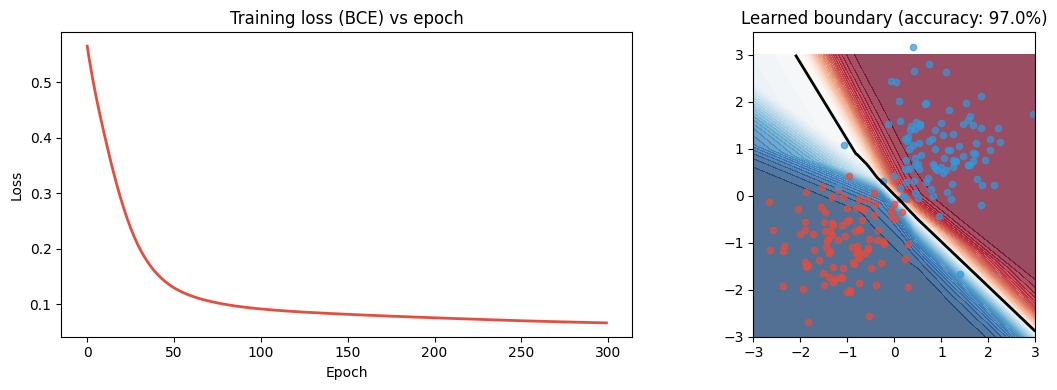

Final loss: 0.0667 | Accuracy: 97.0%


In [2]:
import matplotlib.pyplot as plt

# Train on a small dataset to verify the full loop works
rng = np.random.default_rng(0)
n = 200
X0 = rng.multivariate_normal([-1, -1], [[0.5, 0], [0, 0.5]], n // 2)
X1 = rng.multivariate_normal([1, 1], [[0.5, 0], [0, 0.5]], n // 2)
X_tr = np.vstack([X0, X1]).T  # shape (2, 200)
y_tr = np.array([0] * (n // 2) + [1] * (n // 2), dtype=float)[None, :]  # shape (1, 200)

net2 = MLPNumPy([2, 8, 8, 1], seed=1)
lr = 0.1
losses = []

for epoch in range(300):
    out, cache = net2.forward(X_tr)
    loss = net2.bce_loss(out, y_tr)
    losses.append(loss)
    grads = net2.backward(y_tr, cache)
    net2.update(grads, lr=lr)

preds = (net2.forward(X_tr)[0] > 0.5).astype(int)
acc = (preds == y_tr).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='#e74c3c', lw=2)
ax1.set_title('Training loss (BCE) vs epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T
Z = net2.forward(grid)[0].reshape(xx.shape)
ax2.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.7)
ax2.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
colors = ['#e74c3c', '#3498db']
for cls in [0, 1]:
    mask = (y_tr.ravel() == cls)
    ax2.scatter(X_tr[0, mask], X_tr[1, mask], color=colors[cls], s=20, alpha=0.7)
ax2.set_title(f'Learned boundary (accuracy: {acc:.1%})')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('ch306_backprop.png', dpi=120)
plt.show()
print(f"Final loss: {losses[-1]:.4f} | Accuracy: {acc:.1%}")

## 3. The computation graph view

Every operation in the forward pass is a node. Every edge carries a value forward
and a gradient backward. Backprop is just topological sort + chain rule.

This is exactly what automatic differentiation (autograd) frameworks implement —
PyTorch's `.backward()`, JAX's `jax.grad()`. The framework records the computation
graph during the forward pass and traverses it in reverse on the backward pass.

*(Automatic differentiation introduced conceptually in ch208.)*

---

## 4. Vanishing and exploding gradients

At each layer: $dA^{[l-1]} = W^{[l]\top} \cdot dZ^{[l]}$.

If $\|W^{[l]}\| < 1$ consistently, gradients shrink exponentially with depth → **vanishing gradients**.
If $\|W^{[l]}\| > 1$ consistently → **exploding gradients**.

Mitigations:
- Careful initialisation *(ch308)*: set initial $\|W^{[l]}\|$ to avoid amplification or decay.
- Batch normalisation *(ch310)*: re-normalises activations mid-network.
- Residual connections *(ch316)*: bypass layers so gradients flow directly.
- Gradient clipping *(ch307)*: cap gradient norms before the update.

---

## 5. Summary

- Backprop = chain rule applied in reverse topological order through the computation graph.
- Three equations per layer: activation backward, weight gradient, bias gradient, upstream gradient.
- The cache from the forward pass stores exactly what the backward pass needs.
- Gradient checks (numerical vs analytical) verify the implementation is correct.
- Vanishing/exploding gradients are structural risks addressed by init, normalisation, and architecture.

---

## 6. Forward and backward references

**Used here:** chain rule *(ch215)*, partial derivatives *(ch210)*, matrix transpose *(ch154)*,
forward pass and cache *(ch304)*, loss gradients *(ch305)*, activation derivatives *(ch309)*.

**This will reappear in ch316 — CNN Architectures**, where backprop flows through
convolutional layers (gradients are cross-correlations), and in ch337 — Transformer Block
from Scratch, where attention gradients require careful handling of softmax Jacobians.